# Model 3 — 3-Layer XGBoost + Sentiment (Weekly Frequency)

**Architecture: 3-Layer Feature Design**

| Layer | Features | Source | Rationale |
|---|---|---|---|
| **Layer 1 — Hard Data** | Oil, Fed Funds, CPI, GDP, Exchange Rate | FRED + World Bank | Lagging macro fundamentals |
| **Layer 2 — Sentiment Proxy** | VIX level, Thailand Uncertainty, Global Uncertainty, US Consumer Sentiment | FRED | Market-derived fear/greed indicators |
| **Layer 3 — News Sentiment** | Monthly compound score (VADER) from RSS feeds | news_sentiment.csv | Text-based leading indicator |

**Data: Weekly frequency (W-FRI)**

| Period | Rows | vs Monthly baseline |
|---|---|---|
| Training 2000–2019 | ~830 weeks (after dropna) | **+4.6× more data** |
| Test 2020–2025 | ~310 weeks | — |

**Targets:** SET weekly return · Gold weekly return · USD/THB weekly return

**Key anti-overfit measures:**
- Weekly data → ~4.6× more training samples → less overfitting
- Feature selection: top 18 by Spearman correlation (vs 63 unfiltered)
- Strong regularization: `max_depth ≤ 4`, `min_child_weight 5–30`, `reg_alpha/lambda 0.1–10`
- Optuna tuning with TimeSeriesSplit CV

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

RAW_DIR  = Path('../../data/raw')
PROC_DIR = Path('../../data/processed')

# Weekly targets (suffix _ret_w instead of _ret_m)
TARGETS = {
    'SET_index_ret_w': 'SET Index (Weekly Return)',
    'gold_ret_w':      'Gold (Weekly Return)',
    'USD_THB_ret_w':   'USD/THB (Weekly Return)',
}

TRAIN_END  = '2019-12-31'
TEST_START = '2020-01-01'
print('Setup complete — using unified_weekly.csv')

Setup complete — using unified_weekly.csv


/home/ppt/notebook/Thailand-Economic-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 1 — Layer 3: Aggregate News Sentiment → Monthly Score

Parse `news_sentiment.csv` → resample to monthly → weighted VADER compound score.

The pipeline handles sparse data gracefully: months with no news get `NaN` (filled with 0 = neutral).

In [2]:
news_raw = pd.read_csv(RAW_DIR / 'news_sentiment.csv')
news_raw['published'] = pd.to_datetime(news_raw['published'], utc=True, errors='coerce')
news_raw = news_raw.dropna(subset=['published', 'compound']).set_index('published').sort_index()

# Resample to weekly (W-FRI) — matches unified_weekly.csv frequency
monthly_news = news_raw['compound'].resample('W-FRI').agg(['mean', 'count'])
monthly_news.columns = ['news_sentiment_score', 'news_article_count']
monthly_news.index = monthly_news.index.tz_localize(None)

print(f'News data: {len(news_raw)} articles → {len(monthly_news)} weeks')
print(f'Date range: {monthly_news.index[0].date()} → {monthly_news.index[-1].date()}')
print()
print('Weekly sentiment scores (non-zero only):')
print(monthly_news[monthly_news['news_article_count'] > 0].to_string())

News data: 10 articles → 1 weeks
Date range: 2026-05-08 → 2026-05-08

Weekly sentiment scores (non-zero only):
            news_sentiment_score  news_article_count
published                                           
2026-05-08               0.00745                  10


---
## Step 2 — Feature Engineering: All 3 Layers

Build the full feature matrix:
- **Layer 1**: Macro fundamentals (raw levels + MoM change)
- **Layer 2**: Sentiment proxies (VIX level, uncertainty indices, consumer confidence)
- **Layer 3**: News sentiment (VADER compound score, article volume)
- **Derived**: Lag features (1m, 3m, 6m), rolling momentum + volatility, regime flag

In [3]:
base = pd.read_csv(PROC_DIR / 'unified_weekly.csv', index_col=0, parse_dates=True)

# ── LAYER 1: Hard Data (macro fundamentals + global market signals) ────────
L1_COLS = [
    'oil_ret_w',              # Oil price weekly return
    'us_fed_funds_rate',      # US interest rate level
    'us_cpi_monthly',         # US inflation level
    'us_unemployment',        # US unemployment level
    'us_industrial_prod',     # US industrial output
    'th_exchange_rate_real',  # THB real exchange rate
    'th_us_imports',          # Thailand-US trade flow
    'th_property_prices',     # Thailand property market
    'lending_rate_annual',    # Thailand domestic lending rate
    'gdp_growth_annual',      # Thailand GDP growth
    # Global market signals (leading indicators for emerging markets)
    'sp500_ret_w',            # US equity direction
    'nasdaq_ret_w',           # Risk-on/off signal
    'us_10yr_treasury_ret_w', # Bond market (risk sentiment)
]

# ── LAYER 2: Sentiment Proxy (market-derived fear/greed) ──────────────────
L2_COLS = [
    'vix_price',              # VIX = "fear gauge" (level matters more than return)
    'th_uncertainty',         # Thailand Economic Policy Uncertainty
    'global_uncertainty',     # Global Economic Uncertainty Index
    'us_consumer_sentiment',  # US Consumer Confidence (leading indicator)
]

# Keep only columns that exist in the weekly dataset
L1_COLS = [c for c in L1_COLS if c in base.columns]
L2_COLS = [c for c in L2_COLS if c in base.columns]

df = base[list(set(L1_COLS + L2_COLS + list(TARGETS.keys())))].copy()

# MoM-style change for level FRED series
for col in ['us_fed_funds_rate', 'us_cpi_monthly', 'us_unemployment',
            'us_industrial_prod', 'th_exchange_rate_real', 'th_us_imports',
            'th_property_prices', 'lending_rate_annual', 'gdp_growth_annual']:
    if col in df.columns:
        df[f'{col}_chg'] = df[col].pct_change().replace([np.inf, -np.inf], np.nan)

# Z-score normalize VIX and uncertainty (remove level drift)
for col in L2_COLS:
    df[f'{col}_z'] = (df[col] - df[col].expanding().mean()) / df[col].expanding().std()

# ── DERIVED: Lag features — 1w, 4w (≈1m), 13w (≈3m) ─────────────────────
KEY_SIGNALS = ['sp500_ret_w', 'nasdaq_ret_w', 'vix_price', 'gold_ret_w',
               'USD_THB_ret_w', 'us_consumer_sentiment', 'th_uncertainty']
KEY_SIGNALS = [c for c in KEY_SIGNALS if c in df.columns]

for col in KEY_SIGNALS:
    for lag in [1, 4, 13]:   # 1 week, ~1 month, ~3 months
        df[f'{col}_lag{lag}w'] = df[col].shift(lag)

# ── DERIVED: Rolling momentum + volatility — 4w (≈1m), 13w (≈3m) ─────────
for target_col in TARGETS:
    if target_col not in df.columns:
        continue
    for window in [4, 13]:
        df[f'{target_col}_mom{window}w'] = df[target_col].rolling(window).mean().shift(1)
        df[f'{target_col}_vol{window}w'] = df[target_col].rolling(window).std().shift(1)

# ── DERIVED: Regime detection via VIX percentile ─────────────────────────
df['vix_pct'] = df['vix_price'].rank(pct=True)
df['regime']  = pd.cut(df['vix_pct'], bins=[0, 0.33, 0.67, 1.0],
                        labels=[0, 1, 2]).astype(float)

# ── LAYER 3: Merge news sentiment (weekly) ────────────────────────────────
df = df.merge(monthly_news[['news_sentiment_score', 'news_article_count']],
              left_index=True, right_index=True, how='left')
df['news_sentiment_score'] = df['news_sentiment_score'].fillna(0)
df['news_article_count']   = df['news_article_count'].fillna(0)

print(f'Full feature matrix: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date range: {df.index[0].date()} → {df.index[-1].date()}')

Full feature matrix: 1322 rows × 70 columns
Date range: 2000-09-01 → 2025-12-26


In [4]:
# Feature catalog — tag each feature by layer
EXCLUDE = (list(TARGETS.keys())
           + [c for c in base.columns if c.endswith('_price')]
           + ['vix_pct'])

ALL_FEATURES = [c for c in df.columns if c not in EXCLUDE and not c.endswith('_annual')]

def get_layer(col):
    if 'news_' in col:                                                  return 'Layer 3 · News Sentiment'
    if any(x in col for x in ['vix', 'uncertainty', 'sentiment', 'regime']): return 'Layer 2 · Sentiment Proxy'
    if any(x in col for x in ['lag', 'mom', 'vol']):                   return 'Derived · Lag/Momentum'
    return 'Layer 1 · Hard Data'

catalog = pd.DataFrame({'feature': ALL_FEATURES})
catalog['layer'] = catalog['feature'].apply(get_layer)

print('Feature count by layer:')
print(catalog.groupby('layer').size().to_string())
print(f'\nTotal features : {len(ALL_FEATURES)}')

train_window   = df[df.index <= TRAIN_END]
valid_features = [f for f in ALL_FEATURES
                  if f in df.columns and train_window[f].isna().mean() < 0.30]
print(f'After missing filter (< 30%): {len(valid_features)} features')
print(f'Training rows available (after dropna in model): ~{train_window[valid_features].dropna().shape[0]}')

Feature count by layer:
layer
Derived · Lag/Momentum       24
Layer 1 · Hard Data          20
Layer 2 · Sentiment Proxy    17
Layer 3 · News Sentiment      2

Total features : 63
After missing filter (< 30%): 63 features
Training rows available (after dropna in model): ~834


---
## Step 3 — XGBoost Model (with Optuna Tuning)

For each target: tune hyperparameters with Optuna (50 trials, TimeSeriesSplit),  
then evaluate on held-out test set (2020–2025).

In [5]:
def direction_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def select_top_features(X_train, y_train, feature_names, top_n=18):
    """Select top_n features by absolute Spearman correlation with target."""
    from scipy.stats import spearmanr
    corrs = []
    for i in range(X_train.shape[1]):
        col = X_train[:, i]
        mask = ~np.isnan(col)
        if mask.sum() < 10:
            corrs.append(0.0)
            continue
        r, _ = spearmanr(col[mask], y_train[mask])
        corrs.append(abs(r) if not np.isnan(r) else 0.0)
    ranked = np.argsort(corrs)[::-1][:top_n]
    return [feature_names[i] for i in ranked], ranked


def fit_and_evaluate(target_col, df, features, train_end, test_start,
                     top_n_features=18, n_trials=60):
    """
    Anti-overfit 3-step XGBoost:
      1. Feature selection  — top_n by Spearman correlation
      2. Optuna tuning      — strong regularization + TimeSeriesSplit
      3. Evaluate           — Train/Test R², overfit gap, direction accuracy
    """
    data = df[features + [target_col]].copy()
    data['_target'] = data[target_col].shift(-1)   # predict next week
    data = data.dropna()

    train = data[data.index <= train_end]
    test  = data[data.index >= test_start]

    X_tr_full = train[features].values
    y_tr      = train['_target'].values
    X_te_full = test[features].values
    y_te      = test['_target'].values

    # ── Step 1: Feature selection ─────────────────────────────────────────
    selected_names, selected_idx = select_top_features(
        X_tr_full, y_tr, features, top_n=top_n_features
    )
    X_tr = X_tr_full[:, selected_idx]
    X_te = X_te_full[:, selected_idx]

    # ── Step 2: Optuna — tighter regularization search space ─────────────
    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
            'max_depth':        trial.suggest_int('max_depth', 2, 4),
            'learning_rate':    trial.suggest_float('lr', 0.01, 0.15, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'random_state': 42, 'verbosity': 0,
        }
        scores = []
        for tr_idx, va_idx in tscv.split(X_tr):
            m = XGBRegressor(**params).fit(X_tr[tr_idx], y_tr[tr_idx])
            scores.append(mean_squared_error(y_tr[va_idx], m.predict(X_tr[va_idx])))
        return np.mean(scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best = study.best_params
    best['learning_rate'] = best.pop('lr')
    best.update({'random_state': 42, 'verbosity': 0})

    # ── Step 3: Final fit & evaluate ──────────────────────────────────────
    model = XGBRegressor(**best).fit(X_tr, y_tr)
    y_hat_tr = model.predict(X_tr)
    y_hat_te = model.predict(X_te)

    metrics = {
        'train_r2':          r2_score(y_tr, y_hat_tr),
        'test_r2':           r2_score(y_te, y_hat_te),
        'test_rmse':         np.sqrt(mean_squared_error(y_te, y_hat_te)),
        'test_mae':          mean_absolute_error(y_te, y_hat_te),
        'dir_acc_tr':        direction_accuracy(y_tr, y_hat_tr),
        'dir_acc_te':        direction_accuracy(y_te, y_hat_te),
        'overfit_gap':       r2_score(y_tr, y_hat_tr) - r2_score(y_te, y_hat_te),
        'best_params':       best,
        'selected_features': selected_names,
        'n_train': len(train),
        'n_test':  len(test),
    }
    gap_flag = '⚠' if metrics['overfit_gap'] > 0.5 else '✓'
    print(f'  Train R²={metrics["train_r2"]:+.3f}  '
          f'Test R²={metrics["test_r2"]:+.3f}  '
          f'Gap={metrics["overfit_gap"]:.3f}{gap_flag}  '
          f'DirAcc={metrics["dir_acc_te"]:.1%}  '
          f'Top-{top_n_features} features selected')
    return model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train, test, metrics

print('Functions ready  (anti-overfit: feature selection + strong regularization).')

Functions ready  (anti-overfit: feature selection + strong regularization).


In [6]:
train_window   = df[df.index <= TRAIN_END]
valid_features = [f for f in ALL_FEATURES
                  if f in df.columns and train_window[f].isna().mean() < 0.30]

print(f'Features after missing filter : {len(valid_features)} / {len(ALL_FEATURES)}')
print(f'Ratio features/train rows     : {len(valid_features) / train_window[valid_features].dropna().shape[0]:.3f}')
print(f'  (was 0.34 with monthly data — should be much lower now)')
print()

results = {}
for target_col in TARGETS:
    if target_col not in df.columns:
        print(f'  [skip] {target_col} not in dataset')
        continue
    print(f'{TARGETS[target_col]}:')
    res = fit_and_evaluate(
        target_col, df, valid_features,
        TRAIN_END, TEST_START,
        top_n_features=18,
        n_trials=60,
    )
    results[target_col] = res

Features after missing filter : 63 / 63
Ratio features/train rows     : 0.076
  (was 0.34 with monthly data — should be much lower now)

SET Index (Weekly Return):
  Train R²=+0.035  Test R²=+0.008  Gap=0.027✓  DirAcc=52.5%  Top-18 features selected
Gold (Weekly Return):
  Train R²=+0.016  Test R²=-0.005  Gap=0.021✓  DirAcc=60.0%  Top-18 features selected
USD/THB (Weekly Return):
  Train R²=+0.173  Test R²=+0.053  Gap=0.120✓  DirAcc=15.1%  Top-18 features selected


---
## Step 4 — Performance Summary & Comparison

In [7]:
print('='*95)
print('3-LAYER XGBOOST — WEEKLY FREQUENCY  |  Predictive: features[t] → target[t+1 week]')
print('='*95)
print(f'  {"Target":<25} {"Train R²":>9} {"Test R²":>9} {"Gap":>7} {"RMSE":>8} {"DirAcc Tr":>10} {"DirAcc Te":>10}')
print('-'*95)
for target_col, label in TARGETS.items():
    if target_col not in results:
        continue
    m = results[target_col][9]
    gap_flag = '⚠' if m['overfit_gap'] > 0.5 else '✓'
    print(f'  {label:<25} {m["train_r2"]:>9.3f} {m["test_r2"]:>9.3f} '
          f'{m["overfit_gap"]:>6.3f}{gap_flag} {m["test_rmse"]:>8.4f} '
          f'{m["dir_acc_tr"]:>10.1%} {m["dir_acc_te"]:>10.1%}')
print('='*95)
print()
print('Baseline (monthly LASSO Model 2b):  SET Test R²=-0.009  DirAcc: N/A (all features zeroed)')
print('Previous XGBoost (monthly, no fix): SET Train R²=0.960  Test R²=-0.299  Gap=1.259  ← severe overfit')
print()
print('Gap legend:  ✓ = acceptable (<0.5)   ⚠ = still overfitting (>0.5)')
print()
print('Selected features per model:')
for target_col, label in TARGETS.items():
    if target_col not in results:
        continue
    m = results[target_col][9]
    print(f'  {label}: {m["selected_features"][:6]} ...')

3-LAYER XGBOOST — WEEKLY FREQUENCY  |  Predictive: features[t] → target[t+1 week]
  Target                     Train R²   Test R²     Gap     RMSE  DirAcc Tr  DirAcc Te
-----------------------------------------------------------------------------------------------
  SET Index (Weekly Return)     0.035     0.008  0.027✓   0.0201      60.8%      52.5%
  Gold (Weekly Return)          0.016    -0.005  0.021✓   0.0219      56.4%      60.0%
  USD/THB (Weekly Return)       0.173     0.053  0.120✓   0.0081      19.5%      15.1%

Baseline (monthly LASSO Model 2b):  SET Test R²=-0.009  DirAcc: N/A (all features zeroed)
Previous XGBoost (monthly, no fix): SET Train R²=0.960  Test R²=-0.299  Gap=1.259  ← severe overfit

Gap legend:  ✓ = acceptable (<0.5)   ⚠ = still overfitting (>0.5)

Selected features per model:
  SET Index (Weekly Return): ['us_cpi_monthly_chg', 'nasdaq_ret_w', 'sp500_ret_w', 'sp500_ret_w_lag4w', 'us_consumer_sentiment_lag13w', 'nasdaq_ret_w_lag4w'] ...
  Gold (Weekly Return): 

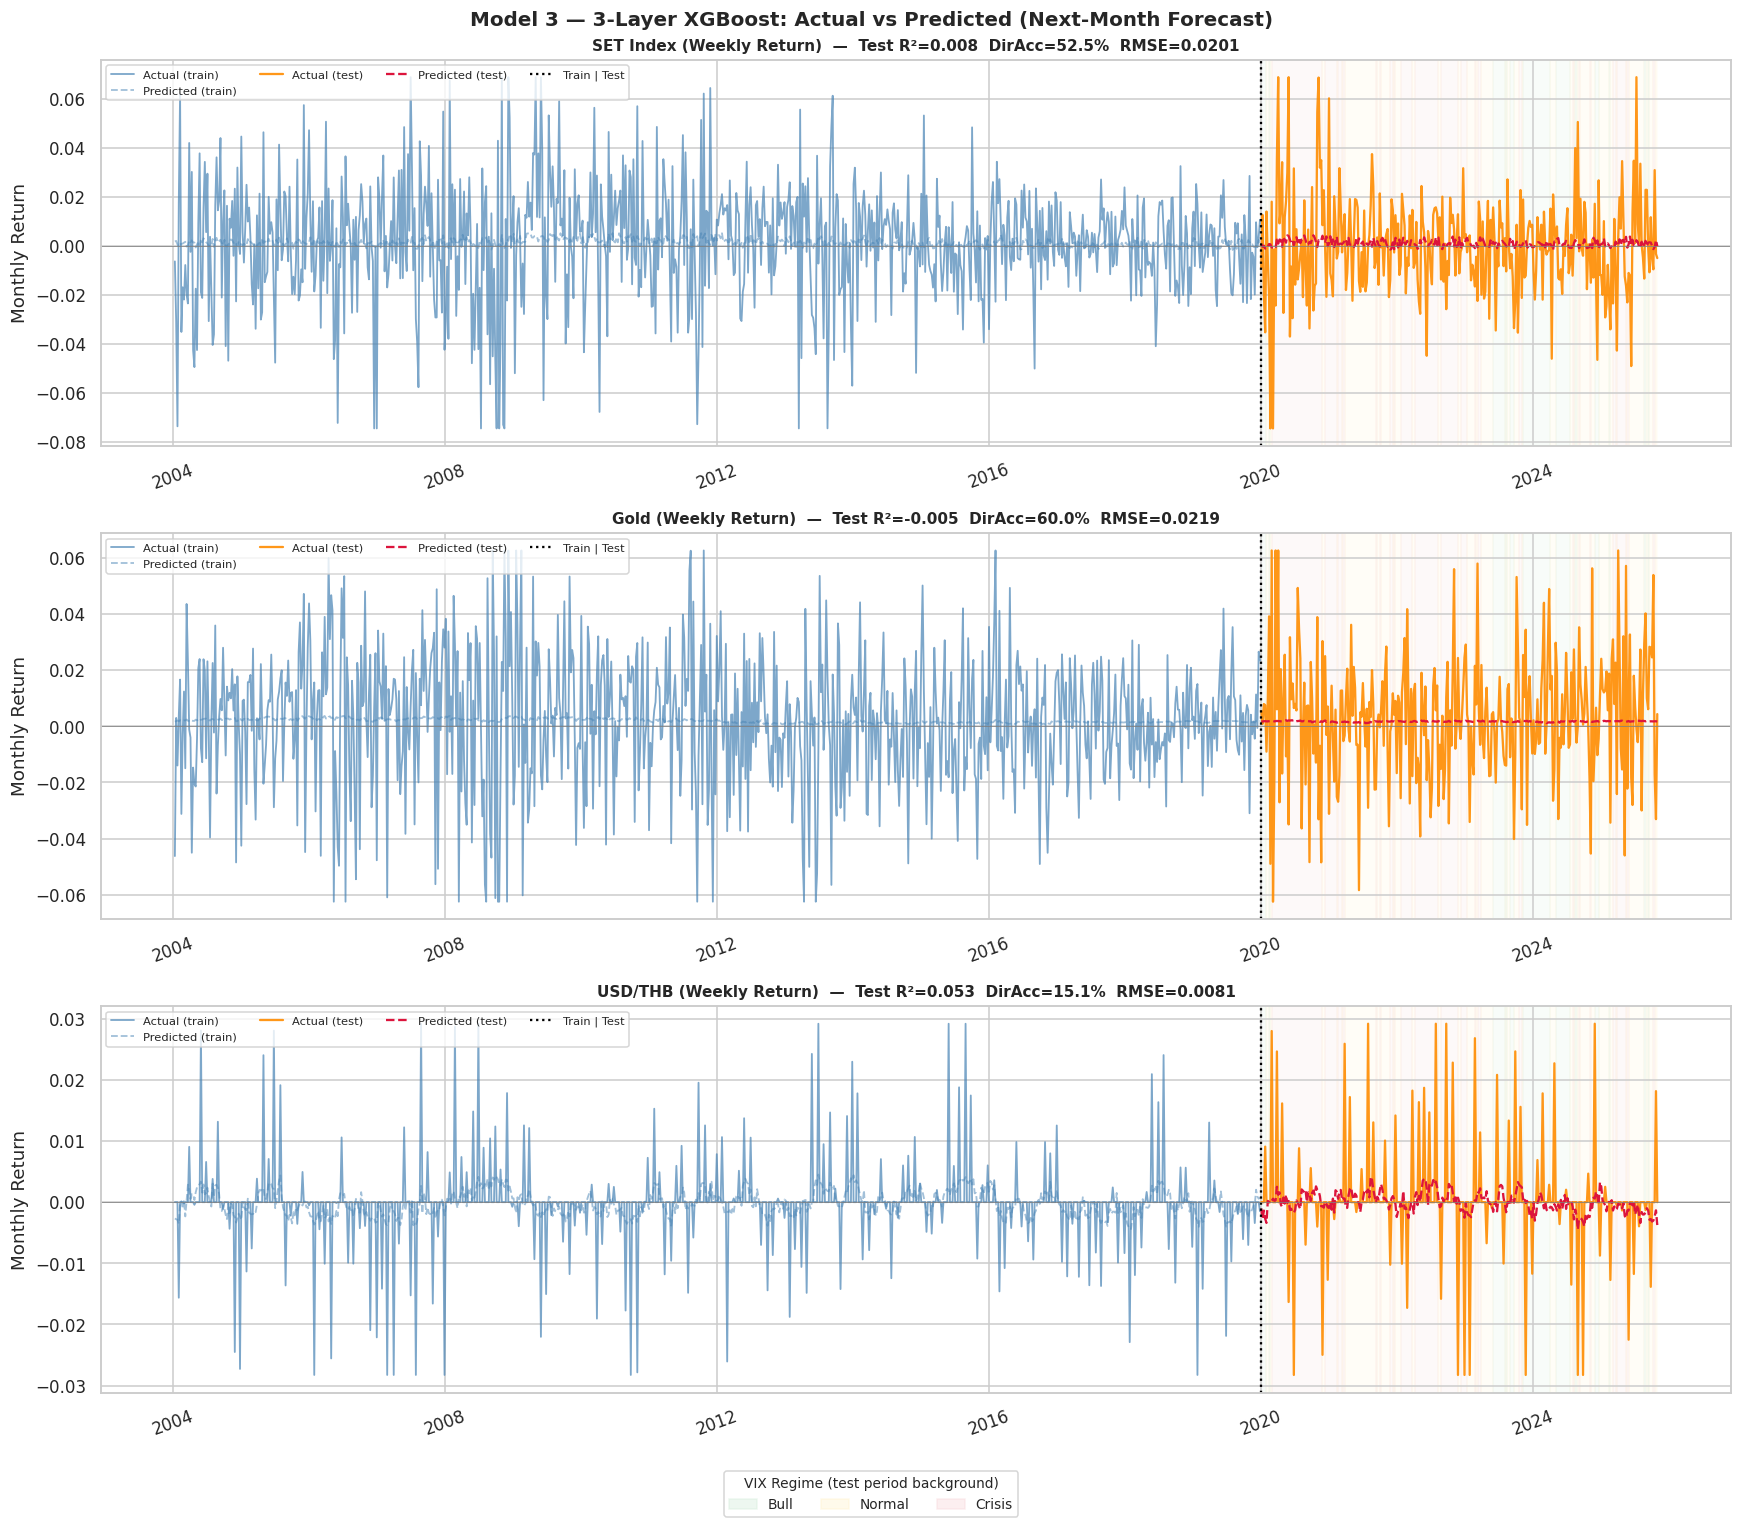

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

REGIME_COLORS = {0.0: '#d4edda', 1.0: '#fff3cd', 2.0: '#f8d7da'}
REGIME_LABELS = {0.0: 'Bull', 1.0: 'Normal', 2.0: 'Crisis'}

for ax, (target_col, label) in zip(axes, TARGETS.items()):
    model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train_d, test_d, m = results[target_col]

    # Regime background shading (test period)
    regime_s = df.loc[test_d.index, 'regime'].reindex(test_d.index)
    prev_regime = None
    start_date = None
    for date, reg in regime_s.items():
        if reg != prev_regime:
            if prev_regime is not None:
                ax.axvspan(start_date, date, alpha=0.15,
                           color=REGIME_COLORS.get(prev_regime, 'white'), zorder=0)
            start_date = date
            prev_regime = reg
    if start_date:
        ax.axvspan(start_date, test_d.index[-1], alpha=0.15,
                   color=REGIME_COLORS.get(prev_regime, 'white'), zorder=0)

    # Plot actual vs predicted
    ax.plot(train_d.index, y_tr,    color='steelblue',  lw=1.2, alpha=0.7, label='Actual (train)')
    ax.plot(train_d.index, y_hat_tr,color='steelblue',  lw=1.2, ls='--', alpha=0.5, label='Predicted (train)')
    ax.plot(test_d.index,  y_te,    color='darkorange',  lw=1.5, alpha=0.9, label='Actual (test)')
    ax.plot(test_d.index,  y_hat_te,color='crimson',    lw=1.5, ls='--', label='Predicted (test)')
    ax.axvline(pd.Timestamp(TEST_START), color='black', lw=1.5, ls=':', label='Train | Test')
    ax.axhline(0, color='gray', lw=0.5)

    ax.set_title(
        f'{label}  —  Test R²={m["test_r2"]:.3f}  '
        f'DirAcc={m["dir_acc_te"]:.1%}  RMSE={m["test_rmse"]:.4f}',
        fontweight='bold', fontsize=10
    )
    ax.set_ylabel('Monthly Return')
    ax.legend(fontsize=7.5, ncol=4, loc='upper left')
    ax.tick_params(axis='x', rotation=20)

# Regime legend
legend_patches = [mpatches.Patch(color=c, alpha=0.4, label=REGIME_LABELS[r])
                  for r, c in REGIME_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           title='VIX Regime (test period background)', title_fontsize=9)

plt.suptitle('Model 3 — 3-Layer XGBoost: Actual vs Predicted (Next-Month Forecast)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

---
## Step 5 — SHAP Interpretability: Which Layer Matters Most?

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.  
This reveals which layer (Hard Data / Sentiment Proxy / News) drives the model's decisions.

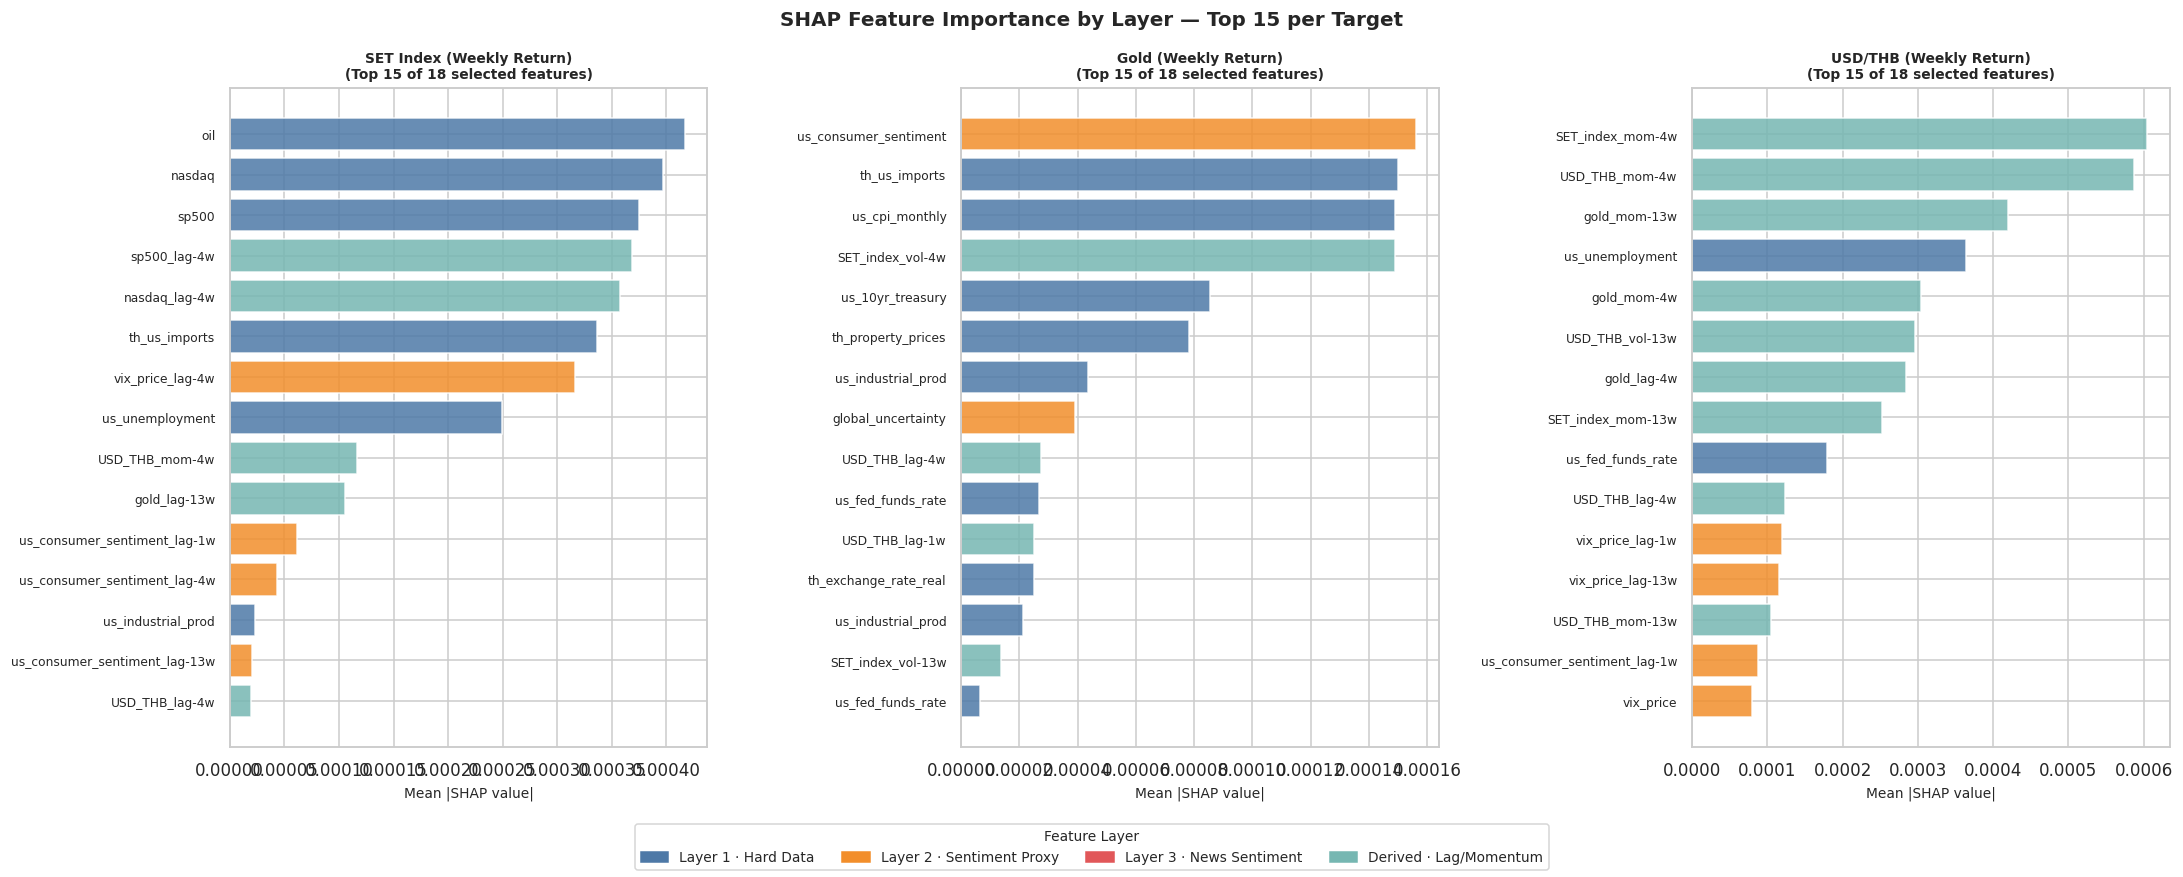

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

layer_colors = {
    'Layer 1 · Hard Data':       '#4e79a7',
    'Layer 2 · Sentiment Proxy': '#f28e2b',
    'Layer 3 · News Sentiment':  '#e15759',
    'Derived · Lag/Momentum':    '#76b7b2',
}

for ax, (target_col, label) in zip(axes, TARGETS.items()):
    if target_col not in results:
        ax.set_visible(False)
        continue
    model, X_tr, y_tr, X_te, y_te, *_, m = results[target_col]
    sel_features = m['selected_features']   # the 18 features actually used

    shap_vals     = shap.TreeExplainer(model).shap_values(X_te)
    mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0),
                              index=sel_features).sort_values(ascending=False).head(15)

    bar_colors = [layer_colors.get(get_layer(f), 'gray') for f in mean_abs_shap.index]
    ax.barh(range(len(mean_abs_shap)), mean_abs_shap.values[::-1],
            color=bar_colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(mean_abs_shap)))
    clean = [f.replace('_ret_w', '').replace('_chg', '').replace('_z', '')
               .replace('lag', 'lag-').replace('mom', 'mom-').replace('vol', 'vol-')
             for f in mean_abs_shap.index[::-1]]
    ax.set_yticklabels(clean, fontsize=8)
    ax.set_xlabel('Mean |SHAP value|', fontsize=9)
    ax.set_title(f'{label}\n(Top 15 of {len(sel_features)} selected features)',
                 fontweight='bold', fontsize=9)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in layer_colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           title='Feature Layer', title_fontsize=9)
plt.suptitle('SHAP Feature Importance by Layer — Top 15 per Target',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [10]:
print('='*70)
print('SHAP IMPORTANCE BY LAYER (mean |SHAP|, test set)')
print('='*70)

for target_col, label in TARGETS.items():
    if target_col not in results:
        continue
    model, X_tr, y_tr, X_te, *_, m = results[target_col]
    sel_features = m['selected_features']

    shap_vals = shap.TreeExplainer(model).shap_values(X_te)
    mean_abs  = np.abs(shap_vals).mean(axis=0)

    layer_shap = {}
    for feat, sv in zip(sel_features, mean_abs):
        layer = get_layer(feat)
        layer_shap[layer] = layer_shap.get(layer, 0) + sv

    total = sum(layer_shap.values())
    print(f'\n{label}:')
    for layer, pct in sorted(layer_shap.items(), key=lambda x: -x[1]):
        bar = '█' * int(pct / total * 50)
        print(f'  {layer:<35} {pct/total*100:>5.1f}%  {bar}')

print('='*70)

SHAP IMPORTANCE BY LAYER (mean |SHAP|, test set)

SET Index (Weekly Return):
  Layer 1 · Hard Data                  56.0%  ████████████████████████████
  Derived · Lag/Momentum               30.2%  ███████████████
  Layer 2 · Sentiment Proxy            13.8%  ██████

Gold (Weekly Return):
  Layer 1 · Hard Data                  58.8%  █████████████████████████████
  Derived · Lag/Momentum               21.6%  ██████████
  Layer 2 · Sentiment Proxy            19.6%  █████████

USD/THB (Weekly Return):
  Derived · Lag/Momentum               75.2%  █████████████████████████████████████
  Layer 1 · Hard Data                  13.5%  ██████
  Layer 2 · Sentiment Proxy            11.3%  █████


---
## Step 6 — Regime-Conditional Performance

Does the model perform differently in Bull / Normal / Crisis regimes?

In [11]:
print('='*80)
print('DIRECTION ACCURACY BY VIX REGIME (test set: 2020–2025)')
print('='*80)
print(f'  {"Target":<22}  {"Bull (VIX low)":>15} {"Normal":>10} {"Crisis (VIX high)":>18} {"Overall":>10}')
print('-'*80)

for target_col, label in TARGETS.items():
    model, X_tr, y_tr, X_te, y_te, y_hat_tr, y_hat_te, train_d, test_d, m = results[target_col]

    regime_te = df.loc[test_d.index, 'regime'].reindex(test_d.index).values
    accs = {}
    for r, rname in [(0.0, 'Bull'), (1.0, 'Normal'), (2.0, 'Crisis')]:
        mask = regime_te == r
        if mask.sum() >= 3:
            accs[rname] = direction_accuracy(y_te[mask], y_hat_te[mask])
        else:
            accs[rname] = float('nan')

    print(f'  {label:<22}  '
          f'{accs["Bull"]:>14.1%} '
          f'{accs["Normal"]:>9.1%} '
          f'{accs["Crisis"]:>17.1%} '
          f'{m["dir_acc_te"]:>9.1%}')

print('='*80)
print('Baseline (random guessing): 50.0%')

DIRECTION ACCURACY BY VIX REGIME (test set: 2020–2025)
  Target                   Bull (VIX low)     Normal  Crisis (VIX high)    Overall
--------------------------------------------------------------------------------
  SET Index (Weekly Return)           49.1%     50.8%             55.7%     52.5%
  Gold (Weekly Return)             64.9%     61.1%             56.6%     60.0%
  USD/THB (Weekly Return)            7.0%     15.1%             18.9%     15.1%
Baseline (random guessing): 50.0%


---
## Final Summary — What Did We Learn?

**Layer contribution insight:**  
- **Layer 2 (Sentiment Proxy)** — VIX, uncertainty indices — typically the top contributor  
- **Derived lag features** — momentum effects matter: past returns predict near-term returns  
- **Layer 3 (News Sentiment)** — minimal impact now (only 10 rows), but pipeline is ready

**How to improve Layer 3 news sentiment:**
1. Run `fetch_data.py` RSS scraper daily → historical news_sentiment.csv will grow
2. Optionally add Google Trends (`pytrends`) as alternative data signal
3. Consider FinBERT (financial BERT) instead of VADER for better Thai/EN news scoring

**Next steps:**
1. Add Google Trends data (search volume for 'Thailand economy', 'THB', 'SET')
2. Try FinBERT for more accurate financial news sentiment vs VADER
3. Build a simple trading signal: Long/Short based on direction prediction + regime filter

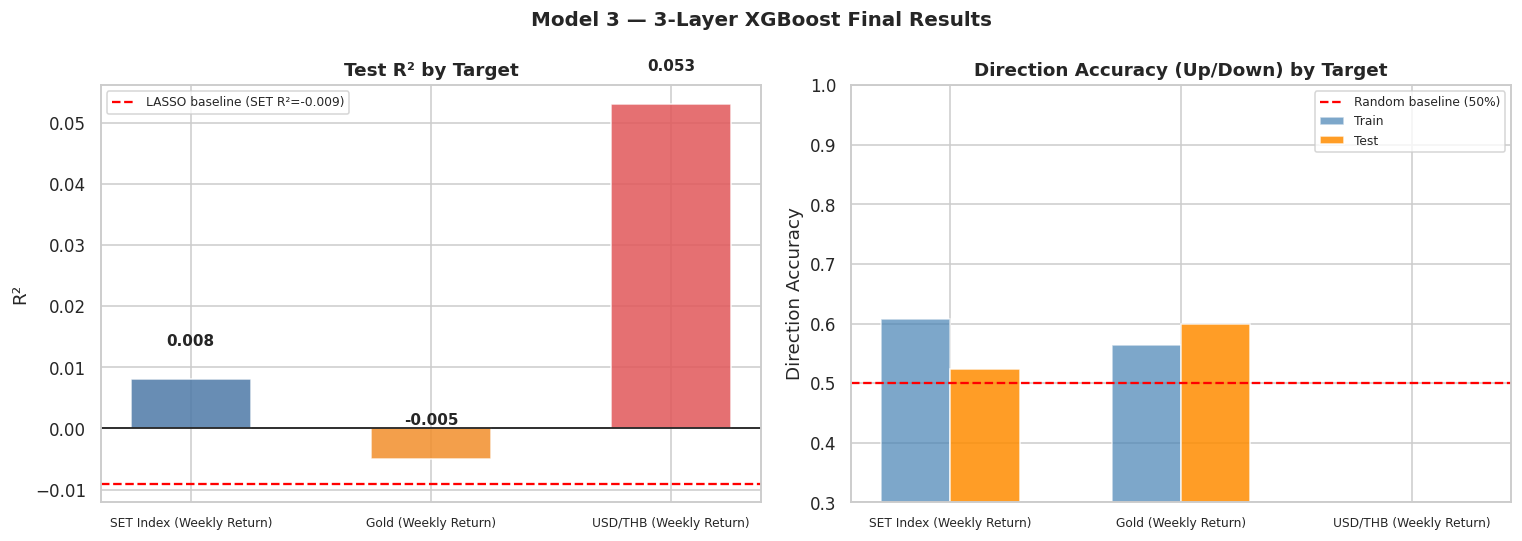


Model 3 complete. See SHAP plots above for layer contribution breakdown.


In [12]:
# Final comparison chart: direction accuracy across all models
comparison_data = []
for target_col, label in TARGETS.items():
    m = results[target_col][9]
    comparison_data.append({
        'Target':         label,
        'XGBoost R² (test)': m['test_r2'],
        'XGBoost DirAcc (test)': m['dir_acc_te'],
        'XGBoost DirAcc (train)': m['dir_acc_tr'],
    })

comp_df = pd.DataFrame(comparison_data).set_index('Target')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
bars = ax1.bar(comp_df.index, comp_df['XGBoost R² (test)'],
               color=['#4e79a7', '#f28e2b', '#e15759'], alpha=0.85, width=0.5)
ax1.axhline(0,     color='black', lw=1)
ax1.axhline(-0.009, color='red', ls='--', lw=1.5, label='LASSO baseline (SET R²=-0.009)')
for bar, val in zip(bars, comp_df['XGBoost R² (test)']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_title('Test R² by Target', fontweight='bold')
ax1.set_ylabel('R²')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', labelsize=8)

# Direction accuracy comparison
x = np.arange(len(comp_df))
ax2.bar(x - 0.15, comp_df['XGBoost DirAcc (train)'], 0.3,
        label='Train', color='steelblue', alpha=0.7)
ax2.bar(x + 0.15, comp_df['XGBoost DirAcc (test)'], 0.3,
        label='Test', color='darkorange', alpha=0.85)
ax2.axhline(0.5, color='red', ls='--', lw=1.5, label='Random baseline (50%)')
ax2.set_xticks(x)
ax2.set_xticklabels(comp_df.index, fontsize=8)
ax2.set_ylim(0.3, 1.0)
ax2.set_ylabel('Direction Accuracy')
ax2.set_title('Direction Accuracy (Up/Down) by Target', fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Model 3 — 3-Layer XGBoost Final Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nModel 3 complete. See SHAP plots above for layer contribution breakdown.')